# Diagnostic Origin Of 850 hPa Temperature Change

This notebook diagnoses the broad western U.S. 850 hPa warming signal using files that already exist in `data/`. It does not submit ERA5/CDS requests or download data.

The diagnostics test three possibilities:

1. 850 hPa is near or below terrain.
2. Instantaneous tendency terms are being compared with a finite-difference temperature change.
3. The available tendency terms leave a residual from analysis increments, interpolation, model physics, or other missing tendencies.

If the optional surface-pressure, terrain, or 850 hPa geopotential files are absent, the notebook prints that clearly and still runs the timing/residual diagnostics that can be computed from the existing pressure-level files.

In [1]:
from pathlib import Path
import os
import zipfile

import numpy as np
import pandas as pd
import xarray as xr

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


def find_project_root(start):
    for path in [start, *start.parents]:
        if (path / "AGENTS.md").exists():
            return path
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
repo_tmp = PROJECT_ROOT / "tmp"
data_dir = PROJECT_ROOT / "data"
table_output_dir = repo_tmp / "origin-of-850-temperature-change" / "tables"
for path in [repo_tmp / "matplotlib", repo_tmp / "cartopy", table_output_dir]:
    path.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))
cartopy_cache = Path.home() / ".local" / "share" / "cartopy"
os.environ.setdefault("CARTOPY_DATA_DIR", str(cartopy_cache if cartopy_cache.exists() else repo_tmp / "cartopy"))

ANALYSIS_DATE = "2017-03-14"
ANALYSIS_HOURS = [f"{hour:02d}:00" for hour in range(24)]
CONUS_AREA = [50.0, -125.0, 24.0, -66.0]
WEST_DOMAIN = {"longitude": slice(-125.0, -95.0), "latitude": slice(50.0, 25.0)}

DATA_PATH = data_dir / "era5_conus_850_t_uv_2017-03-14.nc"
VERTICAL_DATA_PATH = data_dir / "era5_conus_825_850_875_t_omega_2017-03-14.nc"
SURFACE_DATA_PATH = data_dir / "era5_conus_surface_pressure_terrain_2017-03-14.nc"
Z850_DATA_PATH = data_dir / "era5_conus_850_geopotential_2017-03-14.nc"

required_paths = {
    "850 temperature/u/v": DATA_PATH,
    "825/850/875 temperature/omega": VERTICAL_DATA_PATH,
}
optional_paths = {
    "surface pressure and terrain": SURFACE_DATA_PATH,
    "850 hPa geopotential": Z850_DATA_PATH,
}

missing_required = [f"{label}: {path.relative_to(PROJECT_ROOT)}" for label, path in required_paths.items() if not path.exists()]
if missing_required:
    raise FileNotFoundError(
        "Required pressure-level ERA5 files are missing. Download them outside this notebook first:\n"
        + "\n".join(missing_required)
    )

for label, path in optional_paths.items():
    if path.exists():
        print(f"Optional file present: {path.relative_to(PROJECT_ROOT)}")
    else:
        print(f"Optional file missing: {path.relative_to(PROJECT_ROOT)} ({label}); related diagnostics will be skipped.")

print(f"Tables will be written to: {table_output_dir.relative_to(PROJECT_ROOT)}")

Optional file present: data/era5_conus_surface_pressure_terrain_2017-03-14.nc
Optional file present: data/era5_conus_850_geopotential_2017-03-14.nc
Tables will be written to: tmp/origin-of-850-temperature-change/tables


## Load Existing ERA5 Files

The notebook only opens local files. Missing optional files disable the terrain-mask and height-above-ground diagnostics rather than triggering a download.

In [2]:
def open_era5_file(path):
    if zipfile.is_zipfile(path):
        extract_dir = PROJECT_ROOT / "tmp" / "era5-extracted" / path.stem
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(path) as archive:
            archive.extractall(extract_dir)
        nc_files = sorted(extract_dir.glob("*.nc"))
        if not nc_files:
            raise FileNotFoundError(f"No NetCDF files found inside {path}")
        return xr.open_dataset(nc_files[0], engine="netcdf4")
    return xr.open_dataset(path, engine="netcdf4")


def normalize_longitudes(ds):
    if "longitude" not in ds.coords:
        return ds
    lon = ds.longitude
    if float(lon.max()) > 180:
        ds = ds.assign_coords(longitude=(((lon + 180) % 360) - 180)).sortby("longitude")
    return ds


def wanted_valid_times():
    return pd.date_range(f"{ANALYSIS_DATE} 00:00", f"{ANALYSIS_DATE} 23:00", freq="h")


def select_times(ds):
    ds = normalize_longitudes(ds)
    ds = ds.sel(valid_time=wanted_valid_times())
    return ds.sortby("latitude", ascending=False).sortby("longitude")


def select_850_and_times(ds):
    ds = select_times(ds)
    if "pressure_level" in ds.dims:
        ds = ds.sel(pressure_level=850, method="nearest")
    return ds


def select_vertical_levels_and_times(ds):
    ds = select_times(ds)
    ds = ds.sel(pressure_level=[825, 850, 875], method="nearest")
    return ds.sortby("pressure_level")


era5 = select_850_and_times(open_era5_file(DATA_PATH))
vertical_era5 = select_vertical_levels_and_times(open_era5_file(VERTICAL_DATA_PATH))
surface_era5 = select_times(open_era5_file(SURFACE_DATA_PATH)) if SURFACE_DATA_PATH.exists() else None
z850_era5 = select_850_and_times(open_era5_file(Z850_DATA_PATH)) if Z850_DATA_PATH.exists() else None

display(era5)
display(vertical_era5)
if surface_era5 is not None:
    display(surface_era5)
if z850_era5 is not None:
    display(z850_era5)

<xarray.Dataset> Size: 7MB
Dimensions:         (valid_time: 24, latitude: 105, longitude: 237)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 192B 2017-03-14 ... 2017-03-1...
    expver          (valid_time) <U4 384B ...
  * latitude        (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
  * longitude       (longitude) float64 2kB -125.0 -124.8 ... -66.25 -66.0
    number          int64 8B ...
    pressure_level  float64 8B 850.0
Data variables:
    t               (valid_time, latitude, longitude) float32 2MB ...
    u               (valid_time, latitude, longitude) float32 2MB ...
    v               (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-09T23:28 GRIB to CDM+CF via cfgrib-0.9.1...

<xarray.Dataset> Size: 14MB
Dimensions:         (valid_time: 24, pressure_level: 3, latitude: 105,
                     longitude: 237)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 192B 2017-03-14 ... 2017-03-1...
    expver          (valid_time) <U4 384B ...
  * pressure_level  (pressure_level) float64 24B 825.0 850.0 875.0
  * latitude        (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
  * longitude       (longitude) float64 2kB -125.0 -124.8 ... -66.25 -66.0
    number          int64 8B ...
Data variables:
    t               (valid_time, pressure_level, latitude, longitude) float32 7MB ...
    w               (valid_time, pressure_level, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-10T23:58 GRIB to CDM+CF via cfgrib-0.9.1...

<xarray.Dataset> Size: 5MB
Dimensions:     (valid_time: 24, latitude: 105, longitude: 237)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2017-03-14 ... 2017-03-14T23...
    expver      (valid_time) <U4 384B ...
  * latitude    (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
  * longitude   (longitude) float64 2kB -125.0 -124.8 -124.5 ... -66.25 -66.0
    number      int64 8B ...
Data variables:
    z           (valid_time, latitude, longitude) float32 2MB ...
    sp          (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-12T01:52 GRIB to CDM+CF via cfgrib-0.9.1...

<xarray.Dataset> Size: 2MB
Dimensions:         (valid_time: 24, latitude: 105, longitude: 237)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 192B 2017-03-14 ... 2017-03-1...
    expver          (valid_time) <U4 384B ...
  * latitude        (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
  * longitude       (longitude) float64 2kB -125.0 -124.8 ... -66.25 -66.0
    number          int64 8B ...
    pressure_level  float64 8B 850.0
Data variables:
    z               (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-12T01:53 GRIB to CDM+CF via cfgrib-0.9.1...

## Compute Available 850 hPa Tendency Terms

All contribution terms are converted to degrees C per hour, then integrated over each one-hour interval using start-hour, end-hour, and interval-mean timing choices.

In [3]:
R_EARTH_M = 6_371_229.0
SECONDS_PER_HOUR = 3600.0
RD = 287.05
CP = 1004.0
KAPPA = RD / CP
G = 9.80665
P850_PA = 85000.0
P825_PA = 82500.0
P875_PA = 87500.0


def as_time_lat_lon(da):
    drop_dims = [dim for dim in da.dims if dim not in {"valid_time", "latitude", "longitude"}]
    if drop_dims:
        da = da.isel({dim: 0 for dim in drop_dims})
    return da.transpose("valid_time", "latitude", "longitude")


def horizontal_advection_c_per_hour(t_kelvin, u_mps, v_mps):
    t = as_time_lat_lon(t_kelvin)
    u = as_time_lat_lon(u_mps)
    v = as_time_lat_lon(v_mps)

    lat_rad = np.deg2rad(t.latitude.values)
    lon_rad = np.deg2rad(t.longitude.values)
    cos_lat = np.cos(lat_rad)
    cos_lat = np.where(np.abs(cos_lat) < 1e-6, np.nan, cos_lat)

    d_t_dlat_rad = np.gradient(t.values, lat_rad, axis=1, edge_order=2)
    d_t_dlon_rad = np.gradient(t.values, lon_rad, axis=2, edge_order=2)
    d_t_dy = d_t_dlat_rad / R_EARTH_M
    d_t_dx = d_t_dlon_rad / (R_EARTH_M * cos_lat[None, :, None])

    tendency_k_s = -(u.values * d_t_dx + v.values * d_t_dy)
    return xr.DataArray(
        tendency_k_s * SECONDS_PER_HOUR,
        coords=t.coords,
        dims=t.dims,
        name="horizontal_advection_C_per_hour",
        attrs={"units": "C hour-1", "equation": "-(u*dT/dx + v*dT/dy)"},
    )


def vertical_advection_c_per_hour(t_by_pressure_kelvin, omega_850_pa_s):
    t825 = as_time_lat_lon(t_by_pressure_kelvin.sel(pressure_level=825, method="nearest"))
    t875 = as_time_lat_lon(t_by_pressure_kelvin.sel(pressure_level=875, method="nearest"))
    omega = as_time_lat_lon(omega_850_pa_s)
    d_t_dp = (t875 - t825) / (P875_PA - P825_PA)
    tendency = (-omega * d_t_dp) * SECONDS_PER_HOUR
    tendency.name = "vertical_temperature_advection_C_per_hour"
    tendency.attrs.update({"units": "C hour-1", "equation": "-omega*dT/dp"})
    return tendency


def adiabatic_warming_c_per_hour(t_850_kelvin, omega_850_pa_s):
    t = as_time_lat_lon(t_850_kelvin)
    omega = as_time_lat_lon(omega_850_pa_s)
    tendency = (KAPPA * t * omega / P850_PA) * SECONDS_PER_HOUR
    tendency.name = "adiabatic_warming_cooling_C_per_hour"
    tendency.attrs.update({"units": "C hour-1", "equation": "kappa*T*omega/p"})
    return tendency


t850_c = as_time_lat_lon(era5["t"]) - 273.15
t850_c.name = "t850_C"
advection_c_per_hour = horizontal_advection_c_per_hour(era5["t"], era5["u"], era5["v"])

vertical_t850 = vertical_era5["t"].sel(pressure_level=850, method="nearest")
omega850 = vertical_era5["w"].sel(pressure_level=850, method="nearest")
vertical_advection_c_per_hour = vertical_advection_c_per_hour(vertical_era5["t"], omega850)
adiabatic_c_per_hour = adiabatic_warming_c_per_hour(vertical_t850, omega850)

print("Computed horizontal advection, vertical temperature advection, and dry adiabatic terms.")

Computed horizontal advection, vertical temperature advection, and dry adiabatic terms.


## Diagnostic Metrics

By default, `DIAGNOSTIC_VALID_TIME = None` selects the western-domain hour with the largest area-weighted mean T850 warming. Set it to a timestamp string to inspect a specific interval.

In [4]:
DIAGNOSTIC_VALID_TIME = None
WARMING_THRESHOLD_C = 0.5


def western_subset(da):
    return da.sel(**WEST_DOMAIN)


def interval_hours_for(da):
    hours = (
        pd.to_datetime(da.valid_time.values[1:]) - pd.to_datetime(da.valid_time.values[:-1])
    ).total_seconds() / SECONDS_PER_HOUR
    return xr.DataArray(hours, coords={"valid_time": da.valid_time.values[1:]}, dims="valid_time")


def contribution_interval_maps(contribution_c_per_hour):
    start = contribution_c_per_hour.isel(valid_time=slice(None, -1)).assign_coords(
        valid_time=contribution_c_per_hour.valid_time.values[1:]
    )
    end = contribution_c_per_hour.isel(valid_time=slice(1, None))
    hours = interval_hours_for(contribution_c_per_hour)
    return {
        "start": start * hours,
        "end": end * hours,
        "interval_mean": 0.5 * (start + end) * hours,
    }


def coslat_weights_like(da):
    return xr.ones_like(da) * np.cos(np.deg2rad(da.latitude))


def finite_values(*arrays):
    flat = [np.asarray(a).ravel() for a in arrays]
    mask = np.ones(flat[0].shape, dtype=bool)
    for values in flat:
        mask &= np.isfinite(values)
    return [values[mask] for values in flat]


def spatial_corr(a, b, mask=None):
    if b is None:
        return np.nan
    if mask is not None:
        a = a.where(mask)
        b = b.where(mask)
    av, bv = finite_values(a.values, b.values)
    if av.size < 3 or np.nanstd(av) == 0 or np.nanstd(bv) == 0:
        return np.nan
    return float(np.corrcoef(av, bv)[0, 1])


def linear_slope_actual_on_pred(actual, predicted, mask=None):
    if mask is not None:
        actual = actual.where(mask)
        predicted = predicted.where(mask)
    av, pv = finite_values(actual.values, predicted.values)
    if av.size < 3 or np.nanvar(pv) == 0:
        return np.nan
    return float(np.polyfit(pv, av, 1)[0])


def masked_mean(da, mask=None, weights=None):
    values = da if mask is None else da.where(mask)
    if weights is None:
        return float(values.mean(skipna=True))
    weights = weights.where(np.isfinite(values))
    denom = weights.sum(skipna=True)
    if float(denom) == 0:
        return np.nan
    return float((values * weights).sum(skipna=True) / denom)


def masked_std(da, mask=None):
    values = da if mask is None else da.where(mask)
    return float(values.std(skipna=True))


def masked_fraction(condition, base_mask, weights=None):
    condition = condition.where(base_mask)
    if weights is None:
        valid = np.isfinite(condition)
        denom = int(valid.sum())
        if denom == 0:
            return np.nan
        return float(condition.fillna(False).sum() / denom)
    weights = weights.where(base_mask)
    denom = weights.sum(skipna=True)
    if float(denom) == 0:
        return np.nan
    return float(weights.where(condition.fillna(False), 0).sum(skipna=True) / denom)


def error_metrics(actual, predicted, mask=None, weights=None):
    diff = predicted - actual
    return {
        "bias_C": masked_mean(diff, mask=mask, weights=weights),
        "mae_C": masked_mean(abs(diff), mask=mask, weights=weights),
        "rmse_C": np.sqrt(masked_mean(diff**2, mask=mask, weights=weights)),
    }


def save_table_csv(table, filename):
    path = table_output_dir / filename
    table.to_csv(path, index=False)
    print(f"Saved CSV: {path.relative_to(PROJECT_ROOT)}")
    return path


terms = {
    "horizontal_advection": advection_c_per_hour,
    "vertical_temperature_advection": vertical_advection_c_per_hour,
    "adiabatic_warming_cooling": adiabatic_c_per_hour,
}
actual_change = t850_c.diff("valid_time").rename("actual_t850_change_C")
term_interval_sets = {name: contribution_interval_maps(da) for name, da in terms.items()}
predicted_by_method = {
    method: sum(term_maps[method] for term_maps in term_interval_sets.values())
    for method in ["start", "end", "interval_mean"]
}

surface_pressure_hpa = None
terrain_m = None
height_850_agl_m = None
if surface_era5 is not None and "sp" in surface_era5:
    surface_pressure_hpa = (as_time_lat_lon(surface_era5["sp"]) / 100.0).rename("surface_pressure_hPa")
if surface_era5 is not None and "z" in surface_era5:
    terrain_m = (as_time_lat_lon(surface_era5["z"]) / G).rename("terrain_m")
if z850_era5 is not None and "z" in z850_era5 and terrain_m is not None:
    z850_m = as_time_lat_lon(z850_era5["z"]) / G
    height_850_agl_m = (z850_m - terrain_m).rename("height_850_agl_m")

western_actual = western_subset(actual_change)
western_weights = coslat_weights_like(western_actual)
diagnostic_time = (
    pd.Timestamp(DIAGNOSTIC_VALID_TIME)
    if DIAGNOSTIC_VALID_TIME is not None
    else pd.Timestamp(western_actual.weighted(western_weights).mean(("latitude", "longitude")).idxmax().item())
)
print(f"Diagnostic interval ending: {diagnostic_time:%Y-%m-%d %H:%M} UTC")

actual_t = western_actual.sel(valid_time=diagnostic_time)
weights_t = western_weights.sel(valid_time=diagnostic_time)
pred_t = {method: western_subset(da).sel(valid_time=diagnostic_time) for method, da in predicted_by_method.items()}
term_t = {
    name: western_subset(maps["interval_mean"]).sel(valid_time=diagnostic_time)
    for name, maps in term_interval_sets.items()
}
sp_t = western_subset(surface_pressure_hpa).sel(valid_time=diagnostic_time) if surface_pressure_hpa is not None else None
terrain_t = western_subset(terrain_m).sel(valid_time=diagnostic_time) if terrain_m is not None else None
height_agl_t = western_subset(height_850_agl_m).sel(valid_time=diagnostic_time) if height_850_agl_m is not None else None

base_mask = xr.ones_like(actual_t, dtype=bool)
terrain_masks = {"all": base_mask}
if sp_t is not None:
    terrain_masks.update(
        {
            "surface_pressure_gt_850": sp_t > 850.0,
            "surface_pressure_gt_875": sp_t > 875.0,
            "surface_pressure_gt_900": sp_t > 900.0,
        }
    )
else:
    print("Surface pressure is unavailable, so terrain-mask metrics are limited to the all-cells mask.")

Diagnostic interval ending: 2017-03-14 22:00 UTC


In [5]:
metric_rows = []
for mask_name, mask in terrain_masks.items():
    row = {
        "mask": mask_name,
        "grid_fraction_valid": masked_fraction(mask, base_mask),
        "area_weighted_fraction_valid": masked_fraction(mask, base_mask, weights=weights_t),
        "mean_actual_change_C": masked_mean(actual_t, mask=mask),
        "area_weighted_mean_actual_change_C": masked_mean(actual_t, mask=mask, weights=weights_t),
        "std_actual_change_C": masked_std(actual_t, mask=mask),
        "warming_area_fraction_gt_0p5C": masked_fraction(actual_t > WARMING_THRESHOLD_C, mask, weights=weights_t),
    }
    interval_pred = pred_t["interval_mean"]
    row.update(
        {
            "interval_sum_mae_C": error_metrics(actual_t, interval_pred, mask=mask, weights=weights_t)["mae_C"],
            "interval_sum_rmse_C": error_metrics(actual_t, interval_pred, mask=mask, weights=weights_t)["rmse_C"],
        }
    )
    for term_name, term_da in term_t.items():
        row[f"corr_actual_{term_name}"] = spatial_corr(actual_t, term_da, mask=mask)
    metric_rows.append(row)

terrain_metrics_table = pd.DataFrame(metric_rows)
save_table_csv(terrain_metrics_table, "western_terrain_mask_metrics.csv")
display(terrain_metrics_table.round(3))

timing_rows = []
for mask_name, mask in terrain_masks.items():
    for method, predicted in pred_t.items():
        errors = error_metrics(actual_t, predicted, mask=mask, weights=weights_t)
        timing_rows.append(
            {
                "mask": mask_name,
                "timing_method": method,
                "corr_actual_predicted": spatial_corr(actual_t, predicted, mask=mask),
                "slope_actual_on_predicted": linear_slope_actual_on_pred(actual_t, predicted, mask=mask),
                "bias_C": errors["bias_C"],
                "mae_C": errors["mae_C"],
                "rmse_C": errors["rmse_C"],
                "area_weighted_mean_actual_C": masked_mean(actual_t, mask=mask, weights=weights_t),
                "area_weighted_mean_predicted_C": masked_mean(predicted, mask=mask, weights=weights_t),
            }
        )

timing_metrics_table = pd.DataFrame(timing_rows)
save_table_csv(timing_metrics_table, "western_tendency_timing_metrics.csv")
display(timing_metrics_table.round(3))

best_method = (
    timing_metrics_table.sort_values("rmse_C")
    .groupby("timing_method", as_index=False)["rmse_C"]
    .mean()
    .sort_values("rmse_C")
    .iloc[0]["timing_method"]
)
best_pred_t = pred_t[best_method]
residual_t = (actual_t - best_pred_t).rename("residual_C")

residual_rows = []
for mask_name, mask in terrain_masks.items():
    residual_rows.append(
        {
            "mask": mask_name,
            "best_timing_method": best_method,
            "residual_mean_C": masked_mean(residual_t, mask=mask, weights=weights_t),
            "residual_std_C": masked_std(residual_t, mask=mask),
            "residual_mae_C": masked_mean(abs(residual_t), mask=mask, weights=weights_t),
            "area_fraction_abs_residual_gt_0p5C": masked_fraction(abs(residual_t) > 0.5, mask, weights=weights_t),
            "area_fraction_abs_residual_gt_1p0C": masked_fraction(abs(residual_t) > 1.0, mask, weights=weights_t),
            "corr_residual_actual": spatial_corr(residual_t, actual_t, mask=mask),
            "corr_residual_terrain": spatial_corr(residual_t, terrain_t, mask=mask) if terrain_t is not None else np.nan,
            "corr_residual_surface_pressure": spatial_corr(residual_t, sp_t, mask=mask) if sp_t is not None else np.nan,
            "corr_residual_height_850_agl": spatial_corr(residual_t, height_agl_t, mask=mask) if height_agl_t is not None else np.nan,
        }
    )

residual_metrics_table = pd.DataFrame(residual_rows)
save_table_csv(residual_metrics_table, "western_residual_metrics.csv")
display(residual_metrics_table.round(3))

if height_agl_t is not None:
    warming_mask = actual_t > WARMING_THRESHOLD_C
    height_agl_metrics_table = pd.DataFrame(
        [
            {"height_850_agl_bin_m": "0-250", "mean_actual_change_C": masked_mean(actual_t, mask=(height_agl_t >= 0) & (height_agl_t < 250))},
            {"height_850_agl_bin_m": "250-500", "mean_actual_change_C": masked_mean(actual_t, mask=(height_agl_t >= 250) & (height_agl_t < 500))},
            {"height_850_agl_bin_m": "500-1000", "mean_actual_change_C": masked_mean(actual_t, mask=(height_agl_t >= 500) & (height_agl_t < 1000))},
            {"height_850_agl_bin_m": "1000-2000", "mean_actual_change_C": masked_mean(actual_t, mask=(height_agl_t >= 1000) & (height_agl_t < 2000))},
            {"height_850_agl_bin_m": ">2000", "mean_actual_change_C": masked_mean(actual_t, mask=height_agl_t >= 2000)},
        ]
    )
    height_agl_warming_table = pd.DataFrame(
        [
            {
                "threshold_m": threshold,
                "western_warming_area_fraction": masked_fraction(height_agl_t < threshold, warming_mask, weights=weights_t),
            }
            for threshold in [250, 500, 1000]
        ]
    )
    save_table_csv(height_agl_metrics_table, "western_height_850_agl_bins.csv")
    save_table_csv(height_agl_warming_table, "western_warming_height_850_agl_fractions.csv")
    display(height_agl_metrics_table.round(3))
    display(height_agl_warming_table.round(3))

Saved CSV: tmp/origin-of-850-temperature-change/tables/western_terrain_mask_metrics.csv


,mask,grid_fraction_valid,area_weighted_fraction_valid,mean_actual_change_C,area_weighted_mean_actual_change_C,std_actual_change_C,warming_area_fraction_gt_0p5C,interval_sum_mae_C,interval_sum_rmse_C,corr_actual_horizontal_advection,corr_actual_vertical_temperature_advection,corr_actual_adiabatic_warming_cooling
0,all,1.000,1.000,0.567,0.549,0.747,0.475,0.704,0.931,0.220,-0.061,0.072
1,surface_pressure_gt_850,0.769,0.774,0.411,0.398,0.692,0.375,0.556,0.770,0.304,-0.057,0.086
2,surface_pressure_gt_875,0.665,0.671,0.317,0.308,0.614,0.311,0.469,0.654,0.334,-0.029,0.077
3,surface_pressure_gt_900,0.587,0.595,0.255,0.249,0.553,0.261,0.412,0.583,0.290,0.007,0.071


Saved CSV: tmp/origin-of-850-temperature-change/tables/western_tendency_timing_metrics.csv


,mask,timing_method,corr_actual_predicted,slope_actual_on_predicted,bias_C,mae_C,rmse_C,area_weighted_mean_actual_C,area_weighted_mean_predicted_C
0,all,start,0.239,0.398,-0.552,0.711,0.942,0.549,-0.003
1,all,end,0.213,0.334,-0.532,0.722,0.946,0.549,0.017
2,all,interval_mean,0.240,0.412,-0.542,0.704,0.931,0.549,0.007
3,surface_pressure_gt_850,start,0.321,0.456,-0.370,0.566,0.787,0.398,0.028
4,surface_pressure_gt_850,end,0.304,0.407,-0.338,0.577,0.790,0.398,0.060
5,surface_pressure_gt_850,interval_mean,0.333,0.490,-0.354,0.556,0.770,0.398,0.044
6,surface_pressure_gt_875,start,0.360,0.445,-0.269,0.483,0.681,0.308,0.039
7,surface_pressure_gt_875,end,0.351,0.423,-0.219,0.488,0.672,0.308,0.088
8,surface_pressure_gt_875,interval_mean,0.380,0.495,-0.244,0.469,0.654,0.308,0.064
9,surface_pressure_gt_900,start,0.348,0.400,-0.202,0.430,0.617,0.249,0.047


Saved CSV: tmp/origin-of-850-temperature-change/tables/western_residual_metrics.csv


,mask,best_timing_method,residual_mean_C,residual_std_C,residual_mae_C,area_fraction_abs_residual_gt_0p5C,area_fraction_abs_residual_gt_1p0C,corr_residual_actual,corr_residual_terrain,corr_residual_surface_pressure,corr_residual_height_850_agl
0,all,interval_mean,0.542,0.769,0.704,0.512,0.285,0.836,0.594,-0.610,-0.596
1,surface_pressure_gt_850,interval_mean,0.354,0.696,0.556,0.403,0.186,0.770,0.532,-0.549,-0.534
2,surface_pressure_gt_875,interval_mean,0.244,0.616,0.469,0.338,0.134,0.707,0.419,-0.445,-0.420
3,surface_pressure_gt_900,interval_mean,0.170,0.565,0.412,0.285,0.096,0.679,0.304,-0.342,-0.306


Saved CSV: tmp/origin-of-850-temperature-change/tables/western_height_850_agl_bins.csv
Saved CSV: tmp/origin-of-850-temperature-change/tables/western_warming_height_850_agl_fractions.csv


,height_850_agl_bin_m,mean_actual_change_C
0,0-250,1.010
1,250-500,0.783
2,500-1000,0.544
3,1000-2000,0.109
4,>2000,NaN


,threshold_m,western_warming_area_fraction
0,250,0.563
1,500,0.680
2,1000,0.871


## Human-Check Plots

Actual and predicted maps use identical color scales. Residual maps use symmetric color scales. Scatterplots include one-to-one lines and report correlation, RMSE, and bias.

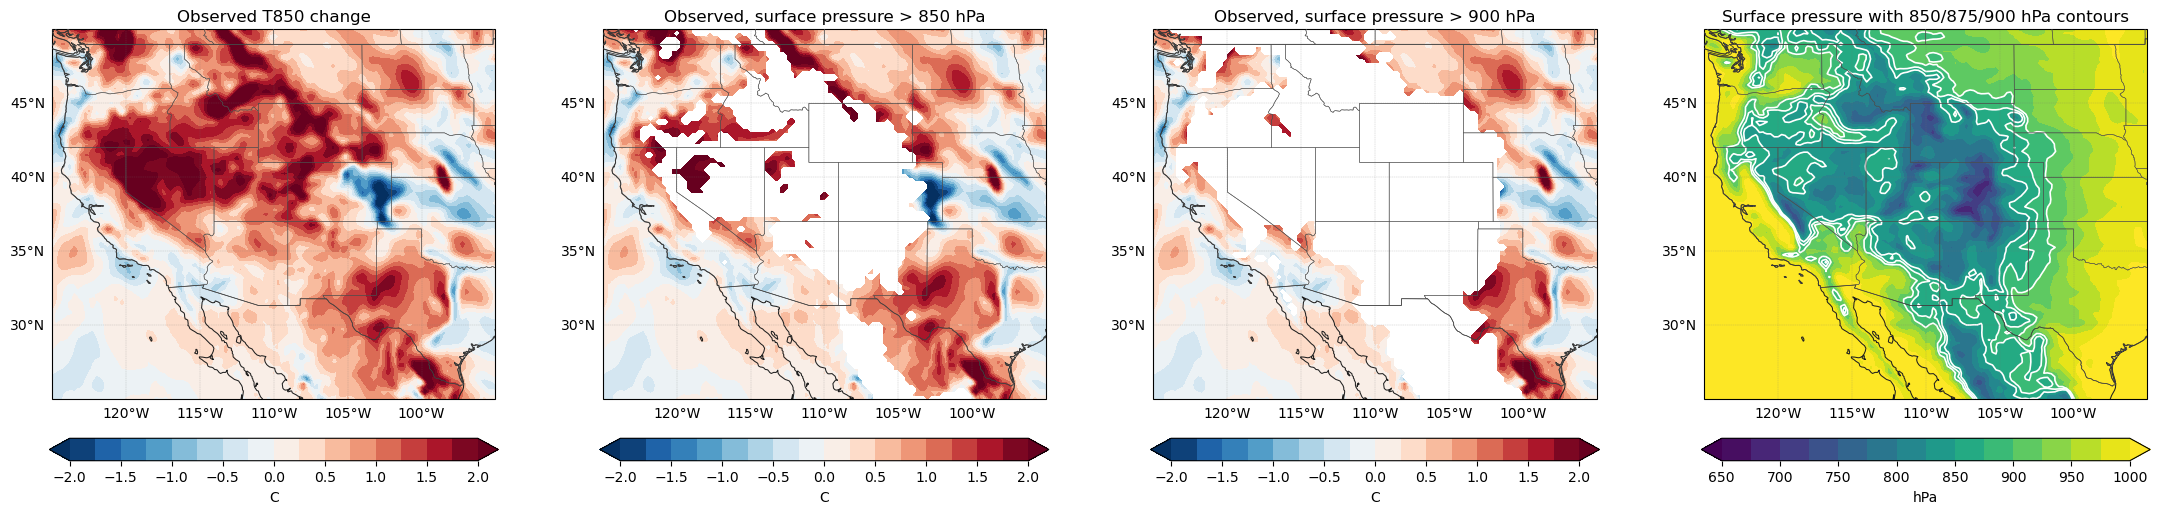

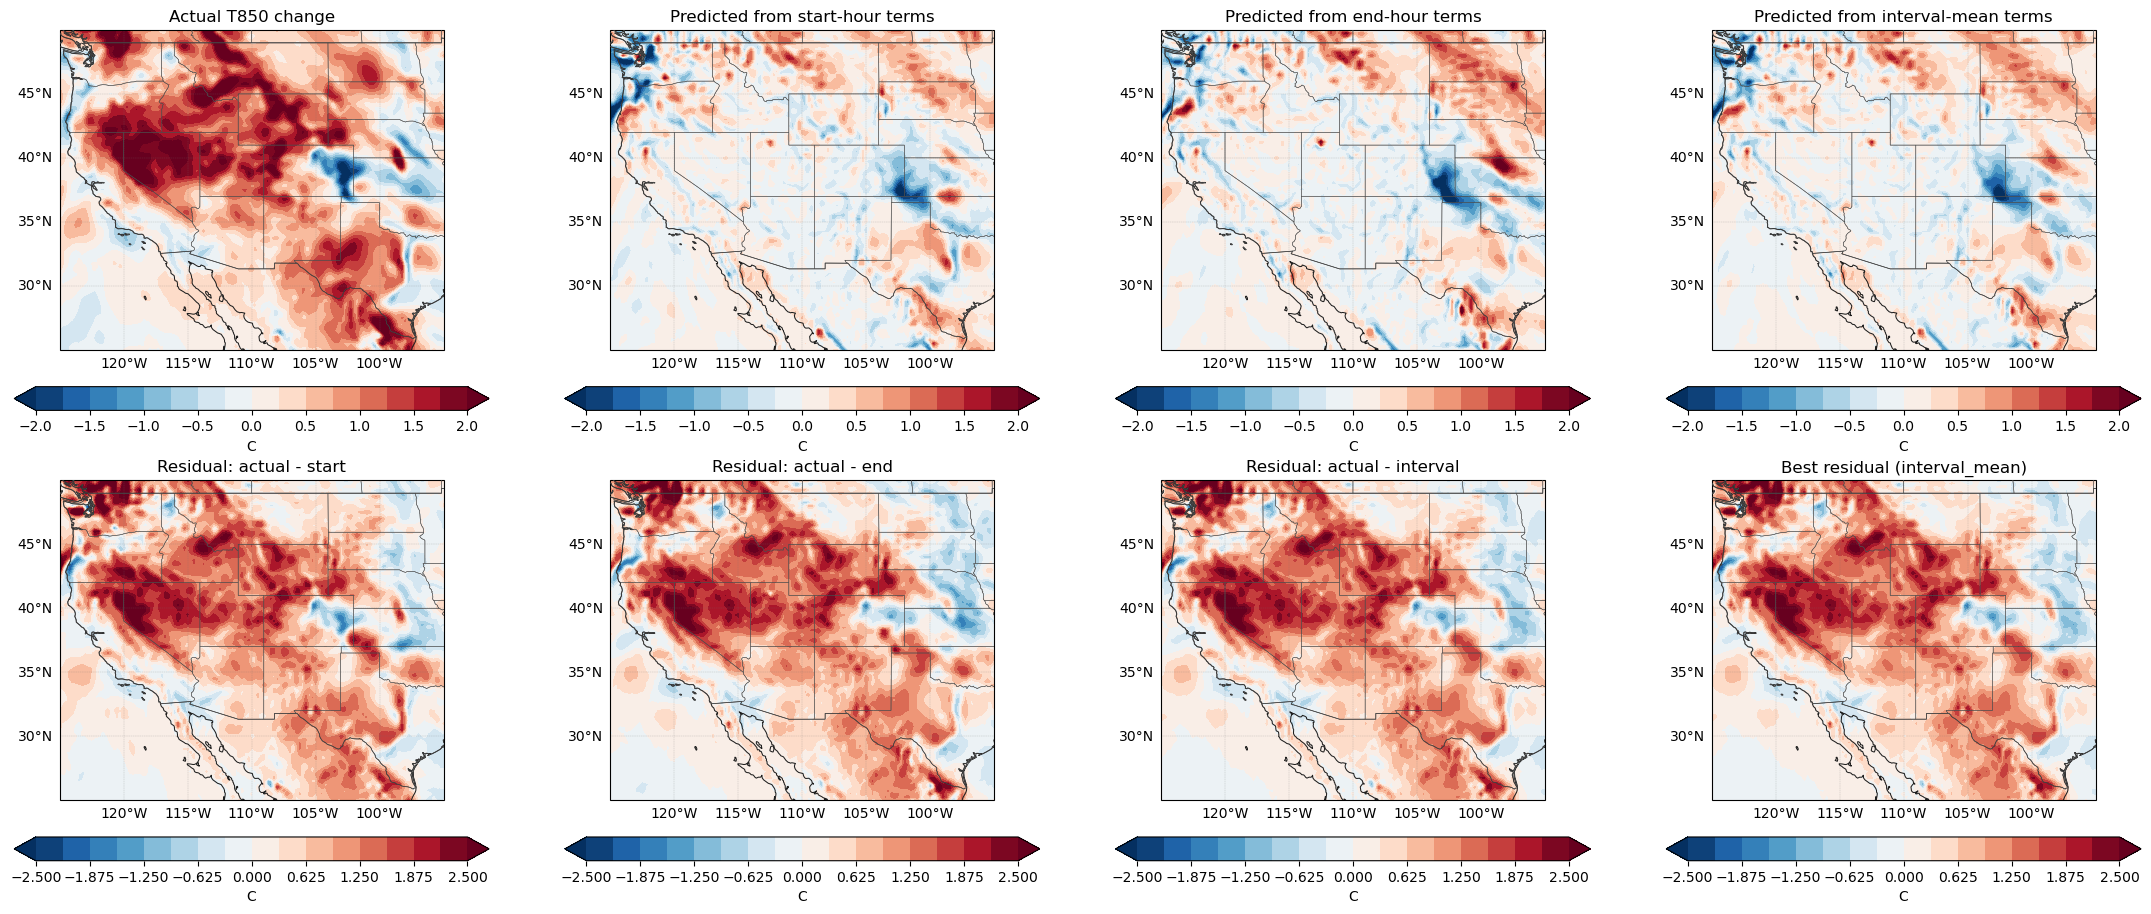

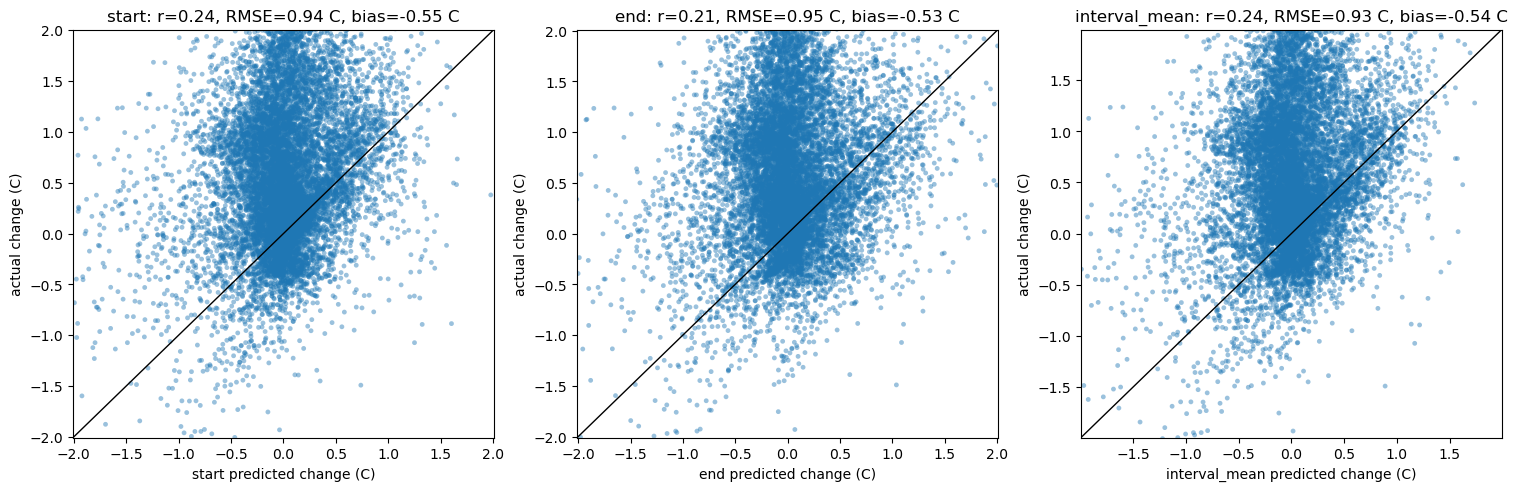

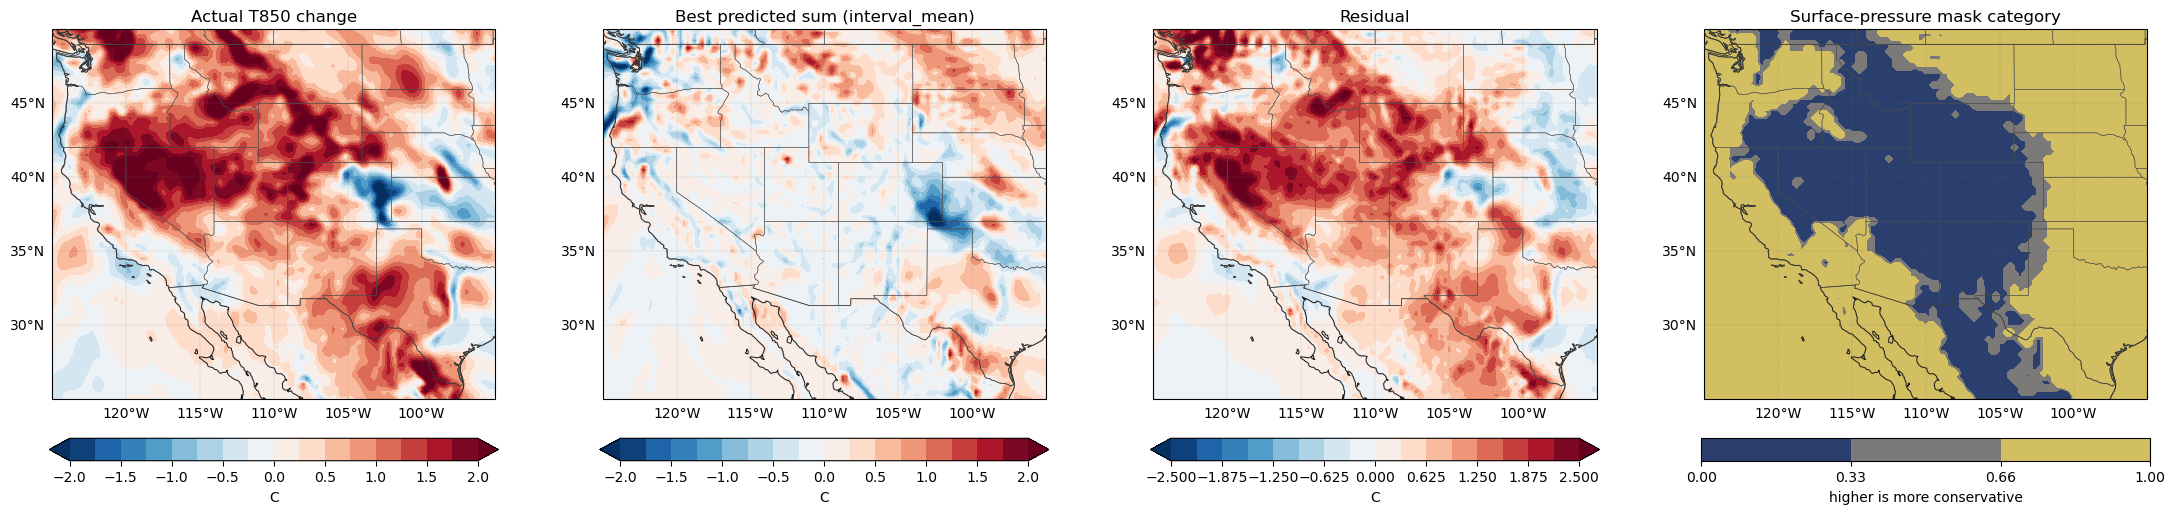

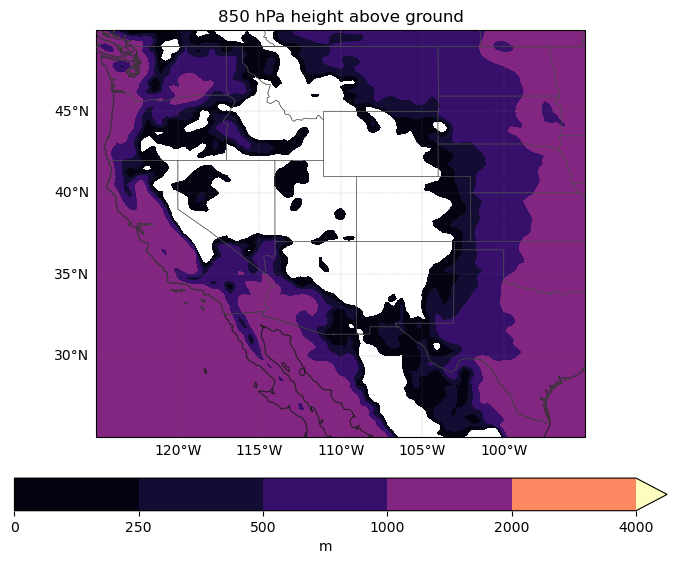

In [6]:
from IPython.display import display
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

projection = ccrs.PlateCarree()


def add_base_map(ax):
    ax.set_extent([-125, -95, 25, 50], crs=projection)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="0.12", linewidth=0.75, zorder=4)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="0.18", linewidth=0.55, zorder=4)
    ax.add_feature(cfeature.STATES.with_scale("50m"), edgecolor="0.30", linewidth=0.35, zorder=4)
    gridlines = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.30,
        color="0.45",
        alpha=0.45,
        linestyle="--",
        zorder=3,
    )
    gridlines.top_labels = False
    gridlines.right_labels = False


def symmetric_levels(*arrays, minimum=0.5, percentile=98, n=17):
    values = np.concatenate([np.asarray(array).ravel() for array in arrays])
    max_abs = float(np.nanpercentile(np.abs(values), percentile))
    max_abs = max(minimum, np.ceil(max_abs * 2) / 2)
    return np.linspace(-max_abs, max_abs, n)


def plot_west_field(ax, da, title, levels=None, cmap="RdBu_r", extend="both"):
    plot = ax.contourf(
        da.longitude,
        da.latitude,
        da,
        levels=levels,
        cmap=cmap,
        extend=extend,
        transform=projection,
    )
    add_base_map(ax)
    ax.set_title(title)
    return plot


change_levels = symmetric_levels(actual_t, *pred_t.values())
residual_levels = symmetric_levels(residual_t)

if sp_t is not None:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5), subplot_kw={"projection": projection}, constrained_layout=True)
    fields = [
        (actual_t, "Observed T850 change"),
        (actual_t.where(sp_t > 850), "Observed, surface pressure > 850 hPa"),
        (actual_t.where(sp_t > 900), "Observed, surface pressure > 900 hPa"),
    ]
    for ax, (field, title) in zip(axes[:3], fields):
        plot = plot_west_field(ax, field, title, levels=change_levels)
        fig.colorbar(plot, ax=ax, orientation="horizontal", pad=0.04, shrink=0.88).set_label("C")
    pressure_plot = axes[3].contourf(
        sp_t.longitude,
        sp_t.latitude,
        sp_t,
        levels=np.arange(650, 1025, 25),
        cmap="viridis",
        extend="both",
        transform=projection,
    )
    axes[3].contour(sp_t.longitude, sp_t.latitude, sp_t, levels=[850, 875, 900], colors="white", linewidths=1.2, transform=projection)
    add_base_map(axes[3])
    axes[3].set_title("Surface pressure with 850/875/900 hPa contours")
    fig.colorbar(pressure_plot, ax=axes[3], orientation="horizontal", pad=0.04, shrink=0.88).set_label("hPa")
    display(fig)
    plt.close(fig)

fig, axes = plt.subplots(2, 4, figsize=(22, 9), subplot_kw={"projection": projection}, constrained_layout=True)
map_fields = [
    (actual_t, "Actual T850 change", change_levels),
    (pred_t["start"], "Predicted from start-hour terms", change_levels),
    (pred_t["end"], "Predicted from end-hour terms", change_levels),
    (pred_t["interval_mean"], "Predicted from interval-mean terms", change_levels),
    (actual_t - pred_t["start"], "Residual: actual - start", residual_levels),
    (actual_t - pred_t["end"], "Residual: actual - end", residual_levels),
    (actual_t - pred_t["interval_mean"], "Residual: actual - interval", residual_levels),
    (residual_t, f"Best residual ({best_method})", residual_levels),
]
for ax, (field, title, levels) in zip(axes.ravel(), map_fields):
    plot = plot_west_field(ax, field, title, levels=levels)
    fig.colorbar(plot, ax=ax, orientation="horizontal", pad=0.04, shrink=0.88).set_label("C")
display(fig)
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for ax, method in zip(axes, ["start", "end", "interval_mean"]):
    predicted = pred_t[method]
    av, pv = finite_values(actual_t.values, predicted.values)
    ax.scatter(pv, av, s=12, alpha=0.45, edgecolors="none")
    lim = max(0.5, np.nanpercentile(np.abs(np.concatenate([av, pv])), 98))
    ax.plot([-lim, lim], [-lim, lim], color="black", linewidth=1.0)
    errors = error_metrics(actual_t, predicted, weights=weights_t)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"{method} predicted change (C)")
    ax.set_ylabel("actual change (C)")
    ax.set_title(
        f"{method}: r={spatial_corr(actual_t, predicted):.2f}, "
        f"RMSE={errors['rmse_C']:.2f} C, bias={errors['bias_C']:.2f} C"
    )
display(fig)
plt.close(fig)

fig, axes = plt.subplots(1, 4, figsize=(22, 5), subplot_kw={"projection": projection}, constrained_layout=True)
plot_specs = [
    (actual_t, "Actual T850 change", change_levels, "RdBu_r", "C"),
    (best_pred_t, f"Best predicted sum ({best_method})", change_levels, "RdBu_r", "C"),
    (residual_t, "Residual", residual_levels, "RdBu_r", "C"),
]
for ax, (field, title, levels, cmap, label) in zip(axes[:3], plot_specs):
    plot = plot_west_field(ax, field, title, levels=levels, cmap=cmap)
    fig.colorbar(plot, ax=ax, orientation="horizontal", pad=0.04, shrink=0.88).set_label(label)
if sp_t is not None:
    mask_field = xr.where(sp_t > 900, 1, xr.where(sp_t > 875, 0.66, xr.where(sp_t > 850, 0.33, 0)))
    mask_plot = plot_west_field(
        axes[3],
        mask_field,
        "Surface-pressure mask category",
        levels=[0, 0.33, 0.66, 1.0],
        cmap="cividis",
        extend="neither",
    )
    fig.colorbar(mask_plot, ax=axes[3], orientation="horizontal", pad=0.04, shrink=0.88).set_label("higher is more conservative")
else:
    axes[3].set_visible(False)
display(fig)
plt.close(fig)

if height_agl_t is not None:
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5), subplot_kw={"projection": projection}, constrained_layout=True)
    height_plot = ax.contourf(
        height_agl_t.longitude,
        height_agl_t.latitude,
        height_agl_t,
        levels=[0, 250, 500, 1000, 2000, 4000],
        cmap="magma",
        extend="max",
        transform=projection,
    )
    add_base_map(ax)
    ax.set_title("850 hPa height above ground")
    fig.colorbar(height_plot, ax=ax, orientation="horizontal", pad=0.04, shrink=0.88).set_label("m")
    display(fig)
    plt.close(fig)

## Metric-Based Conclusion

The conclusion below is intentionally threshold-based rather than visual-only.

In [7]:
def percent_change(from_value, to_value):
    if pd.isna(from_value) or abs(from_value) < 1e-9:
        return np.nan
    return 100.0 * (to_value - from_value) / abs(from_value)


all_row = terrain_metrics_table.query("mask == 'all'").iloc[0]
has_valid900_mask = "surface_pressure_gt_900" in set(terrain_metrics_table["mask"])
valid900_row = (
    terrain_metrics_table.query("mask == 'surface_pressure_gt_900'").iloc[0]
    if has_valid900_mask
    else all_row
)
mean_change_pct = percent_change(all_row["area_weighted_mean_actual_change_C"], valid900_row["area_weighted_mean_actual_change_C"])
warming_area_drop_pp = 100.0 * (
    valid900_row["warming_area_fraction_gt_0p5C"] - all_row["warming_area_fraction_gt_0p5C"]
)
rmse_change_pct = percent_change(all_row["interval_sum_rmse_C"], valid900_row["interval_sum_rmse_C"])
terrain_sensitive = has_valid900_mask and (
    abs(mean_change_pct) > 30
    or abs(warming_area_drop_pp) > 20
    or (np.isfinite(rmse_change_pct) and rmse_change_pct < -20)
)

method_summary = timing_metrics_table.groupby("timing_method").agg(
    mean_corr=("corr_actual_predicted", "mean"),
    mean_rmse_C=("rmse_C", "mean"),
    mean_predicted_C=("area_weighted_mean_predicted_C", "mean"),
).sort_values("mean_rmse_C")
end_row = method_summary.loc["end"]
interval_row = method_summary.loc["interval_mean"]
end_worse = (
    interval_row["mean_corr"] - end_row["mean_corr"] > 0.15
    or end_row["mean_rmse_C"] > 1.2 * interval_row["mean_rmse_C"]
    or np.sign(end_row["mean_predicted_C"]) != np.sign(all_row["area_weighted_mean_actual_change_C"])
)

residual_all = residual_metrics_table.query("mask == 'all'").iloc[0]
has_residual_valid900_mask = "surface_pressure_gt_900" in set(residual_metrics_table["mask"])
residual_valid900 = (
    residual_metrics_table.query("mask == 'surface_pressure_gt_900'").iloc[0]
    if has_residual_valid900_mask
    else residual_all
)
residual_large = (
    residual_all["residual_mae_C"] > 0.5
    or residual_all["area_fraction_abs_residual_gt_1p0C"] > 0.25
    or residual_all["corr_residual_actual"] > 0.6
)
residual_terrain_sensitive = (
    (np.isfinite(residual_all["corr_residual_surface_pressure"]) and abs(residual_all["corr_residual_surface_pressure"]) > 0.4)
    or (np.isfinite(residual_all["corr_residual_terrain"]) and abs(residual_all["corr_residual_terrain"]) > 0.4)
    or (
        has_residual_valid900_mask
        and residual_all["residual_mae_C"] > 0
        and residual_valid900["residual_mae_C"] < 0.8 * residual_all["residual_mae_C"]
    )
)

print("Diagnostic conclusion")
if has_valid900_mask:
    print(
        "- The western 850 hPa warming is "
        + ("strongly" if terrain_sensitive else "not strongly")
        + " sensitive to terrain masking because valid900 changes the area-weighted mean by "
        + f"{mean_change_pct:.1f}% and the warming-area fraction by {warming_area_drop_pp:.1f} percentage points."
    )
else:
    print(
        "- The western 850 hPa terrain sensitivity cannot be evaluated until surface pressure is loaded; "
        "only the all-cells mask was available."
    )
print(
    "- The instantaneous-vs-finite-difference issue is "
    + ("important" if end_worse else "not dominant")
    + f" because best timing is {best_method}; end-hour mean RMSE is {end_row['mean_rmse_C']:.2f} C versus "
    + f"{interval_row['mean_rmse_C']:.2f} C for interval-mean terms."
)
print(
    "- The residual is "
    + ("large" if residual_large else "small to moderate")
    + f" and suggests incomplete budget closure: best-method residual MAE is {residual_all['residual_mae_C']:.2f} C and "
    + f"{100.0 * residual_all['area_fraction_abs_residual_gt_1p0C']:.1f}% of the area exceeds 1.0 C."
)
print(
    "- The residual is "
    + ("terrain/pressure-level sensitive." if residual_terrain_sensitive else "not mainly tied to the terrain metrics available here.")
)
print(
    "- Because this is ERA5 reanalysis, hourly T850 differences can include data assimilation increments and are not guaranteed "
    "to equal diagnostic dynamical tendency terms unless the full model tendency budget is available."
)
print(
    "- The next most useful test would be to add the full model-analysis tendency budget or rerun the same diagnostics on model "
    "forecast steps where assimilation increments are absent."
)

Diagnostic conclusion
- The western 850 hPa warming is strongly sensitive to terrain masking because valid900 changes the area-weighted mean by -54.7% and the warming-area fraction by -21.3 percentage points.
- The instantaneous-vs-finite-difference issue is not dominant because best timing is interval_mean; end-hour mean RMSE is 0.75 C versus 0.73 C for interval-mean terms.
- The residual is large and suggests incomplete budget closure: best-method residual MAE is 0.70 C and 28.5% of the area exceeds 1.0 C.
- The residual is terrain/pressure-level sensitive.
- Because this is ERA5 reanalysis, hourly T850 differences can include data assimilation increments and are not guaranteed to equal diagnostic dynamical tendency terms unless the full model tendency budget is available.
- The next most useful test would be to add the full model-analysis tendency budget or rerun the same diagnostics on model forecast steps where assimilation increments are absent.
